# Prédiction du Nutri-Score avec CatBoost & Optuna
## Régression sur le dataset Open Food Facts

Ce notebook prédit le **nutriscore_score** (valeur numérique continue, de -15 à +40) à partir des données nutritionnelles pour 100g de produit.  
Le grade (A–E) est ensuite reconstitué par conversion du score prédit.

**Pipeline :** Chargement → Nettoyage → Feature Engineering → Split 50/50 → Baseline XGB → Optuna CatBoost → Évaluation

## 1. Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
)
from xgboost import XGBRegressor
import optuna
from catboost import CatBoostRegressor

In [2]:
INPUT_PATH = "https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz"
OUTPUT_PATH = '../data/openfoodfacts_regression_clean.csv'
FINAL_OUTPUT_PATH = '../data/openfoodfacts_regression_training_ready.csv'

# Colonnes nutritionnelles (features brutes)
nutriscore_cols = [
    'energy_100g', 'fat_100g', 'saturated-fat_100g',
    'sugars_100g', 'fiber_100g', 'proteins_100g', 'carbohydrates_100g',
    'salt_100g'
]

# Cible numérique
target = 'nutriscore_score'
identity_cols = ['code', 'product_name', 'nutriscore_grade']
cols = nutriscore_cols + [target] + identity_cols

## 2. Chargement & nettoyage du dataset

In [3]:
def process_data(file_path, cols, chunk_size=20000):
    reader = pd.read_csv(
        file_path, compression='gzip', sep='\t',
        on_bad_lines='skip', chunksize=chunk_size,
        low_memory=False, usecols=cols
    )
 
    clean_chunks = []
    print("Lecture des blocs...")
    
    for i, chunk in enumerate(reader):
 
        temp_chunk = chunk.copy()
 
        # 1. Nettoyage de la Cible (Target)
        # On supprime les lignes où le score numérique manque
        temp_chunk = temp_chunk.dropna(subset=[target])
        cols_to_convert = nutriscore_cols + [target]
 
        # 2. Conversion numérique des nutriments
        for col in cols_to_convert:
            temp_chunk[col] = pd.to_numeric(temp_chunk[col], errors='coerce')
 
        # Filtre de réalisme pour le score (Officiel : -15 à +40)
        temp_chunk = temp_chunk[(temp_chunk[target] >= -15) & (temp_chunk[target] <= 40)]            
 
        # Remplissage des nutriments manquants par 0 (Imputation)
        temp_chunk[nutriscore_cols] = temp_chunk[nutriscore_cols].fillna(0)
        
        # 3. Filtres Outliers (0-100g et Energie)
        for col in nutriscore_cols:
            if col != 'energy_100g':
                temp_chunk = temp_chunk[(temp_chunk[col] >= 0) & (temp_chunk[col] <= 100)]
        
        temp_chunk = temp_chunk[(temp_chunk['energy_100g'] >= 0) & (temp_chunk['energy_100g'] < 4000)]
 
        # 4. Gestion de l'identité
        temp_chunk['product_name'] = temp_chunk['product_name'].fillna('Unknown Product')
        temp_chunk = temp_chunk.drop_duplicates(subset=['code'])
 
         # 5. Stockage du bloc propre
        if not temp_chunk.empty:
            clean_chunks.append(temp_chunk)
        
        if i % 10 == 0:
            print(f"Bloc {i} chargé...")
    
    print("Fusion de tous les blocs...")
    df_final = pd.concat(clean_chunks, ignore_index=True)
    
    return df_final
 
 
# Lancement
df_raw = process_data(INPUT_PATH, cols)

Lecture des blocs...
Bloc 0 chargé...
Bloc 10 chargé...
Bloc 20 chargé...
Bloc 30 chargé...
Bloc 40 chargé...
Bloc 50 chargé...
Bloc 60 chargé...
Bloc 70 chargé...
Bloc 80 chargé...
Bloc 90 chargé...
Bloc 100 chargé...
Bloc 110 chargé...
Bloc 120 chargé...
Bloc 130 chargé...
Bloc 140 chargé...
Bloc 150 chargé...
Bloc 160 chargé...
Bloc 170 chargé...
Bloc 180 chargé...
Bloc 190 chargé...
Bloc 200 chargé...
Bloc 210 chargé...
Bloc 220 chargé...
Fusion de tous les blocs...


In [4]:
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
df_raw.to_csv(OUTPUT_PATH, index=False, encoding='utf-8')

print(f"Fichier sauvegardé ici : {OUTPUT_PATH}")

Fichier sauvegardé ici : ../data/openfoodfacts_regression_clean.csv


## 3. Exploration initiale

In [5]:
# Copie de travail
df = df_raw.copy()

print("Shape initiale :", df.shape)
print("\nTypes :")
display(df.dtypes)

print("\nValeurs manquantes :")
display(df.isna().sum().sort_values(ascending=False))

Shape initiale : (1352678, 12)

Types :


code                   object
product_name           object
nutriscore_score      float64
nutriscore_grade       object
energy_100g           float64
fat_100g              float64
saturated-fat_100g    float64
carbohydrates_100g    float64
sugars_100g           float64
fiber_100g            float64
proteins_100g         float64
salt_100g             float64
dtype: object


Valeurs manquantes :


code                  0
product_name          0
nutriscore_score      0
nutriscore_grade      0
energy_100g           0
fat_100g              0
saturated-fat_100g    0
carbohydrates_100g    0
sugars_100g           0
fiber_100g            0
proteins_100g         0
salt_100g             0
dtype: int64

## 4. Feature engineering

In [6]:
# Colonnes utiles
feature_cols = nutriscore_cols.copy()
id_cols = ['code', 'product_name', 'nutriscore_grade']
target_col = target

# Suppression des doublons globaux sur le code
df = df.drop_duplicates(subset=['code']).copy()

# On garde uniquement les lignes avec une cible connue
df = df[df[target_col].notna()].copy()

# Conversion de sécurité
for col in feature_cols + [target_col]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Imputation simple sur les colonnes nutritionnelles
df[feature_cols] = df[feature_cols].fillna(0)

# Suppression des lignes aberrantes sur la cible
df = df[df[target_col].between(-15, 40)].copy()

print("Shape après nettoyage :", df.shape)
df.head()

Shape après nettoyage : (1352678, 12)


,code,product_name,nutriscore_score,nutriscore_grade,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g
0,7,granola Bio le Chocolaté,4.0,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,8,Unknown Product,6.0,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,9,xytitol pastilles,-11.0,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,13,Powdered peanut butter,3.0,c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,15,Madeleines ChocoLait,20.0,e,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# Nombre de nutriments non nuls par ligne
df['non_zero_features'] = (df[feature_cols] > 0).sum(axis=1)

# Option: on enlève les lignes sans aucune vraie info nutritionnelle
df = df[df['non_zero_features'] > 0].copy()

print("Shape après retrait des lignes sans info nutritionnelle :", df.shape)
df[['non_zero_features'] + feature_cols].head()

Shape après retrait des lignes sans info nutritionnelle : (408985, 13)


,non_zero_features,energy_100g,fat_100g,saturated-fat_100g,sugars_100g,fiber_100g,proteins_100g,carbohydrates_100g,salt_100g
85,8,697.100000,6.400000,1.30,1.9,0.8,6.700000,20.0,0.0009
86,7,1928.500000,28.000000,13.80,18.0,0.0,6.000000,46.5,0.6490
97,3,1357.900028,36.700001,12.70,0.0,0.0,0.000000,0.0,0.0000
98,7,1771.899957,35.299999,12.20,4.1,0.0,22.299999,5.1,3.9000
99,7,1569.200000,22.700000,12.29,0.2,0.0,40.500000,2.4,3.8500


In [8]:
# Variables dérivées
df['total_macro_100g'] = (
    df['fat_100g'] +
    df['carbohydrates_100g'] +
    df['proteins_100g'] +
    df['fiber_100g']
)

df['sugar_to_carb_ratio'] = np.where(
    df['carbohydrates_100g'] > 0,
    df['sugars_100g'] / df['carbohydrates_100g'],
    0
)

df['satfat_to_fat_ratio'] = np.where(
    df['fat_100g'] > 0,
    df['saturated-fat_100g'] / df['fat_100g'],
    0
)

df['protein_to_energy_ratio'] = np.where(
    df['energy_100g'] > 0,
    df['proteins_100g'] / df['energy_100g'],
    0
)

df['fiber_to_carb_ratio'] = np.where(
    df['carbohydrates_100g'] > 0,
    df['fiber_100g'] / df['carbohydrates_100g'],
    0
)

derived_cols = [
    'non_zero_features',
    'total_macro_100g',
    'sugar_to_carb_ratio',
    'satfat_to_fat_ratio',
    'protein_to_energy_ratio',
    'fiber_to_carb_ratio'
]

all_features = feature_cols + derived_cols

print("Nombre total de features :", len(all_features))
df[all_features + [target_col]].head()

Nombre total de features : 14


,energy_100g,fat_100g,saturated-fat_100g,sugars_100g,fiber_100g,proteins_100g,carbohydrates_100g,salt_100g,non_zero_features,total_macro_100g,sugar_to_carb_ratio,satfat_to_fat_ratio,protein_to_energy_ratio,fiber_to_carb_ratio,nutriscore_score
85,697.100000,6.400000,1.30,1.9,0.8,6.700000,20.0,0.0009,8,33.900000,0.095000,0.203125,0.009611,0.04,5.0
86,1928.500000,28.000000,13.80,18.0,0.0,6.000000,46.5,0.6490,7,80.500000,0.387097,0.492857,0.003111,0.00,23.0
97,1357.900028,36.700001,12.70,0.0,0.0,0.000000,0.0,0.0000,3,36.700001,0.000000,0.346049,0.000000,0.00,14.0
98,1771.899957,35.299999,12.20,4.1,0.0,22.299999,5.1,3.9000,7,62.699998,0.803922,0.345609,0.012585,0.00,35.0
99,1569.200000,22.700000,12.29,0.2,0.0,40.500000,2.4,3.8500,7,65.600000,0.083333,0.541410,0.025809,0.00,33.0


### Fonction de conversion score → grade (A–E)
Définie une seule fois ici, réutilisée dans toute la suite.

In [9]:
def score_to_grade(score):
    """Convertit un nutriscore_score numérique en grade A–E."""
    if score <= -1:
        return 'A'
    elif score <= 2:
        return 'B'
    elif score <= 10:
        return 'C'
    elif score <= 18:
        return 'D'
    else:
        return 'E'

## 5. Split train/test & protocole anti-fuite

### Protocole
- Split **50/50** figé après nettoyage complet (~270 000 produits).
- Le modèle est entraîné **uniquement sur `train_df`** puis évalué **une seule fois** sur `test_df`.
- `nutriscore_score` est uniquement la cible `y` — jamais dans `X`.
- `nutriscore_grade` n'entre jamais dans `X`.
- Le modèle **n'est pas réentraîné** sur l'ensemble complet des données dans ce notebook.

In [10]:

# Dataset final pour la régression
training_df = df[all_features + [target_col]].dropna().copy()

print("Shape training_df :", training_df.shape)
display(training_df.head())

# Split définitif 50/50 APRES nettoyage complet des ~270000 produits
train_df, test_df = train_test_split(
    training_df,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

train_df = train_df.copy()
test_df = test_df.copy()

print("\nShape train_df :", train_df.shape)
print("Shape test_df  :", test_df.shape)
print("Proportion train :", round(len(train_df) / len(training_df), 3))
print("Proportion test  :", round(len(test_df) / len(training_df), 3))


Shape training_df : (408985, 15)


,energy_100g,fat_100g,saturated-fat_100g,sugars_100g,fiber_100g,proteins_100g,carbohydrates_100g,salt_100g,non_zero_features,total_macro_100g,sugar_to_carb_ratio,satfat_to_fat_ratio,protein_to_energy_ratio,fiber_to_carb_ratio,nutriscore_score
85,697.100000,6.400000,1.30,1.9,0.8,6.700000,20.0,0.0009,8,33.900000,0.095000,0.203125,0.009611,0.04,5.0
86,1928.500000,28.000000,13.80,18.0,0.0,6.000000,46.5,0.6490,7,80.500000,0.387097,0.492857,0.003111,0.00,23.0
97,1357.900028,36.700001,12.70,0.0,0.0,0.000000,0.0,0.0000,3,36.700001,0.000000,0.346049,0.000000,0.00,14.0
98,1771.899957,35.299999,12.20,4.1,0.0,22.299999,5.1,3.9000,7,62.699998,0.803922,0.345609,0.012585,0.00,35.0
99,1569.200000,22.700000,12.29,0.2,0.0,40.500000,2.4,3.8500,7,65.600000,0.083333,0.541410,0.025809,0.00,33.0



Shape train_df : (204492, 15)
Shape test_df  : (204493, 15)
Proportion train : 0.5
Proportion test  : 0.5


In [11]:

# Séparation stricte features / cible sur les deux moitiés
X_train = train_df[all_features].copy()
y_train = train_df[target_col].copy()

X_test = test_df[all_features].copy()
y_test = test_df[target_col].copy()

print("Shape X_train :", X_train.shape)
print("Shape y_train :", y_train.shape)
print("Shape X_test  :", X_test.shape)
print("Shape y_test  :", y_test.shape)


Shape X_train : (204492, 14)
Shape y_train : (204492,)
Shape X_test  : (204493, 14)
Shape y_test  : (204493,)


In [12]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Vérifications anti data leakage
for forbidden_col in [target_col, 'nutriscore_grade']:
    assert forbidden_col not in X_train.columns, f"{forbidden_col} fuite dans X_train"
    assert forbidden_col not in X_test.columns, f"{forbidden_col} fuite dans X_test"

assert len(set(train_df.index) & set(test_df.index)) == 0, "Chevauchement entre train et test"
assert len(X_train) + len(X_test) == len(training_df), "Le split ne couvre pas tout le dataset"

print("Aucune fuite détectée :")
print(" - target absente de X_train et X_test")
print(" - nutriscore_grade absent de X_train et X_test")
print(" - aucun chevauchement entre train_df et test_df")
print(" - split 50/50 effectué après nettoyage complet")


Aucune fuite détectée :
 - target absente de X_train et X_test
 - nutriscore_grade absent de X_train et X_test
 - aucun chevauchement entre train_df et test_df
 - split 50/50 effectué après nettoyage complet


In [13]:
# On garde exactement les features construites dans le notebook
selected_features = all_features.copy()

print('Nombre de features retenues :', len(selected_features))
print('Features retenues :')
selected_features

Nombre de features retenues : 14
Features retenues :


['energy_100g',
 'fat_100g',
 'saturated-fat_100g',
 'sugars_100g',
 'fiber_100g',
 'proteins_100g',
 'carbohydrates_100g',
 'salt_100g',
 'non_zero_features',
 'total_macro_100g',
 'sugar_to_carb_ratio',
 'satfat_to_fat_ratio',
 'protein_to_energy_ratio',
 'fiber_to_carb_ratio']

In [14]:
# Vérification explicite des colonnes utilisées
print('La cible est-elle dans les features ? ', target_col in selected_features)
print('nutriscore_grade est-il dans les features ? ', 'nutriscore_grade' in selected_features)

La cible est-elle dans les features ?  False
nutriscore_grade est-il dans les features ?  False


## 6. Sauvegarde du dataset d'entraînement final

In [15]:

final_training_df = training_df[selected_features + [target_col]].copy()

print('Shape final_training_df :', final_training_df.shape)
display(final_training_df.head())

print("\nLe modèle ne sera PAS entraîné sur final_training_df en entier.")
print("Il sera entraîné uniquement sur train_df puis évalué sur test_df.")


Shape final_training_df : (408985, 15)


,energy_100g,fat_100g,saturated-fat_100g,sugars_100g,fiber_100g,proteins_100g,carbohydrates_100g,salt_100g,non_zero_features,total_macro_100g,sugar_to_carb_ratio,satfat_to_fat_ratio,protein_to_energy_ratio,fiber_to_carb_ratio,nutriscore_score
85,697.100000,6.400000,1.30,1.9,0.8,6.700000,20.0,0.0009,8,33.900000,0.095000,0.203125,0.009611,0.04,5.0
86,1928.500000,28.000000,13.80,18.0,0.0,6.000000,46.5,0.6490,7,80.500000,0.387097,0.492857,0.003111,0.00,23.0
97,1357.900028,36.700001,12.70,0.0,0.0,0.000000,0.0,0.0000,3,36.700001,0.000000,0.346049,0.000000,0.00,14.0
98,1771.899957,35.299999,12.20,4.1,0.0,22.299999,5.1,3.9000,7,62.699998,0.803922,0.345609,0.012585,0.00,35.0
99,1569.200000,22.700000,12.29,0.2,0.0,40.500000,2.4,3.8500,7,65.600000,0.083333,0.541410,0.025809,0.00,33.0



Le modèle ne sera PAS entraîné sur final_training_df en entier.
Il sera entraîné uniquement sur train_df puis évalué sur test_df.


In [16]:
FINAL_OUTPUT_PATH = '../data/openfoodfacts_regression_training_ready.csv'
os.makedirs(os.path.dirname(FINAL_OUTPUT_PATH), exist_ok=True)

final_training_df.to_csv(FINAL_OUTPUT_PATH, index=False, encoding='utf-8')
print(f"Dataset prêt sauvegardé ici : {FINAL_OUTPUT_PATH}")

Dataset prêt sauvegardé ici : ../data/openfoodfacts_regression_training_ready.csv


## 7. Modélisation

In [17]:
# On garde exactement les features retenues
X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

print("Shape X_train_sel :", X_train_sel.shape)
print("Shape X_test_sel  :", X_test_sel.shape)

Shape X_train_sel : (204492, 14)
Shape X_test_sel  : (204493, 14)


### 7.1 Modèle baseline — XGBoost (hyperparamètres par défaut)

In [19]:
xgb_model_baseline = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror"
)

xgb_model_baseline.fit(X_train_sel, y_train)
xgb_pred_baseline = xgb_model_baseline.predict(X_test_sel)

results_compare = {
    "Baseline_MAE": mean_absolute_error(y_test, xgb_pred_baseline),
    "Baseline_RMSE": mean_squared_error(y_test, xgb_pred_baseline) ** 0.5,
    "Baseline_R2": r2_score(y_test, xgb_pred_baseline),
}

results_compare

{'Baseline_MAE': 1.056759700651969,
 'Baseline_RMSE': 1.8892709039887114,
 'Baseline_R2': 0.9632705965866659}

### 7.2 XGBoost optimisé — Optuna

In [20]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
        "objective": "reg:squarederror"
    }
    model = XGBRegressor(**params)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_sel, y_train, cv=cv,
                              scoring="neg_root_mean_squared_error", n_jobs=-1)
    return -scores.mean()

# Sampler avec seed fixé pour la reproductibilité (symétrique avec CatBoost)
sampler_xgb = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="minimize", sampler=sampler_xgb)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Meilleur RMSE CV XGB Optuna :", study.best_value)
print("Meilleurs paramètres :")
print(study.best_params)

[I 2026-03-27 09:55:20,140] A new study created in memory with name: no-name-35ebe214-32a0-4b2c-a577-be4a97634806


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-27 09:55:30,410] Trial 0 finished with value: 1.8214982268615927 and parameters: {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.08960785365368121, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_alpha': 2.915443189153755, 'reg_lambda': 0.25378155082656645}. Best is trial 0 with value: 1.8214982268615927.
[I 2026-03-27 09:55:33,661] Trial 1 finished with value: 1.9896405778088877 and parameters: {'n_estimators': 767, 'max_depth': 3, 'learning_rate': 0.1827602783178572, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 2, 'gamma': 0.9170225492671691, 'reg_alpha': 0.016480446427978974, 'reg_lambda': 0.12561043700013563}. Best is trial 0 with value: 1.8214982268615927.
[I 2026-03-27 09:55:37,360] Trial 2 finished with value: 1.9238793148667408 and parameters: {'n_estimators': 545, 'max_depth': 5, 'learning_rate': 0.06252287916406214, 'subsample'

In [21]:

best_params = study.best_params.copy()
best_params.update({
    "random_state": 42,
    "n_jobs": -1,
    "objective": "reg:squarederror"
})

xgb_model_optuna = XGBRegressor(**best_params)

xgb_model_optuna.fit(X_train_sel, y_train)

xgb_pred_optuna = xgb_model_optuna.predict(X_test_sel)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Résultats du XGBoost optimisé avec optuna")
print("XGB Optuna - MAE  :", mean_absolute_error(y_test, xgb_pred_optuna))
print("XGB Optuna - RMSE :", mean_squared_error(y_test, xgb_pred_optuna) ** 0.5)
print("XGB Optuna - R2   :", r2_score(y_test, xgb_pred_optuna))
print("Résultats du XGBoost de base")
print("XGBoost - MAE  :", mean_absolute_error(y_test, xgb_pred_baseline))
print("XGBoost - RMSE :", mean_squared_error(y_test, xgb_pred_baseline) ** 0.5)
print("XGBoost - R2   :", r2_score(y_test, xgb_pred_baseline))

Résultats du XGBoost optimisé avec optuna
XGB Optuna - MAE  : 0.896037198953484
XGB Optuna - RMSE : 1.7689646867591344
XGB Optuna - R2   : 0.967799417465396
Résultats du XGBoost de base
XGBoost - MAE  : 1.056759700651969
XGBoost - RMSE : 1.8892709039887114
XGBoost - R2   : 0.9632705965866659


### 7.3 CatBoost optimisé — Optuna

In [25]:
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def objective_catboost(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 300, 1200),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-2, 20.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_seed": 42,
        "verbose": 0
    }

    model = CatBoostRegressor(**params)

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        model,
        X_train_sel,
        y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    return -scores.mean()

sampler = optuna.samplers.TPESampler(seed=42)
study_cat = optuna.create_study(direction="minimize", sampler=sampler)

study_cat.optimize(objective_catboost, n_trials=50, show_progress_bar=True)

print("Meilleur RMSE CV CatBoost :", study_cat.best_value)
print("Meilleurs paramètres CatBoost :")
print(study_cat.best_params)

best_cat_params = study_cat.best_params.copy()
best_cat_params.update({
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "random_seed": 42,
    "verbose": 0
})

cat_model_optuna = CatBoostRegressor(**best_cat_params)
cat_model_optuna.fit(X_train_sel, y_train)

cat_pred_optuna = cat_model_optuna.predict(X_test_sel)

print("\nCatBoost Optuna - MAE  :", mean_absolute_error(y_test, cat_pred_optuna))
print("CatBoost Optuna - RMSE :", mean_squared_error(y_test, cat_pred_optuna) ** 0.5)
print("CatBoost Optuna - R2   :", r2_score(y_test, cat_pred_optuna))

[I 2026-03-27 10:05:47,223] A new study created in memory with name: no-name-24b7021e-b217-405c-b2d5-e8bc0f93d72c


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-27 10:06:11,327] Trial 0 finished with value: 1.8157693162738309 and parameters: {'iterations': 637, 'depth': 10, 'learning_rate': 0.08960785365368121, 'l2_leaf_reg': 0.9466503798478173, 'random_strength': 0.004207988669606638, 'bagging_temperature': 0.7799726016810132}. Best is trial 0 with value: 1.8157693162738309.
[I 2026-03-27 10:06:24,642] Trial 1 finished with value: 1.873869516105503 and parameters: {'iterations': 352, 'depth': 10, 'learning_rate': 0.06054365855469249, 'l2_leaf_reg': 2.174547098137362, 'random_strength': 0.0012087541473056963, 'bagging_temperature': 4.8495492608099715}. Best is trial 0 with value: 1.8157693162738309.


Exception ignored in: <function ResourceTracker.__del__ at 0x1036d1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[I 2026-03-27 10:06:35,768] Trial 2 finished with value: 2.0678984947486674 and parameters: {'iterations': 1050, 'depth': 5, 'learning_rate': 0.017240892195821537, 'l2_leaf_reg': 0.040311020093778335, 'random_strength': 0.016480446427978974, 'bagging_temperature': 2.6237821581611893}. Best is trial 0 with value: 1.8157693162738309.
[I 2026-03-27 10:06:44,599] Trial 3 finished with value: 1.9193678068998619 and parameters: {'iterations': 689, 'depth': 6, 'learning_rate': 0.06252287916406214, 'l2_leaf_reg': 0.028871770589042903, 'random_strength': 0.01474275315991467, 'bagging_temperature': 1.8318092164684585}. Best is trial 0 with value: 1.8157693162738309.
[I 2026-03-27 10:07:01,942] Trial 4 finished with value: 1.9466929870152554 and parameters: {'iterations': 710, 'depth': 9, 'learning_rate': 0.018187859051288217, 'l2_leaf_reg': 0.4983142493044819, 'random_strength': 0.23423849847112918, 'bagging_temperature': 0.23225206359998862}. Best is trial 0 with value: 1.8157693162738309.
[I 2

Exception ignored in: <function ResourceTracker.__del__ at 0x106d09bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[I 2026-03-27 10:19:58,667] Trial 35 finished with value: 1.8157056520666903 and parameters: {'iterations': 1024, 'depth': 10, 'learning_rate': 0.04926096492495621, 'l2_leaf_reg': 0.2093531978514521, 'random_strength': 0.03000743822936989, 'bagging_temperature': 4.7204384838591125}. Best is trial 29 with value: 1.8002367894021596.
[I 2026-03-27 10:20:32,550] Trial 36 finished with value: 1.8084594687375357 and parameters: {'iterations': 898, 'depth': 10, 'learning_rate': 0.09426804036968997, 'l2_leaf_reg': 0.6870075021745187, 'random_strength': 0.35398666478724927, 'bagging_temperature': 4.240262399993517}. Best is trial 29 with value: 1.8002367894021596.
[I 2026-03-27 10:21:14,503] Trial 37 finished with value: 1.8301753794236582 and parameters: {'iterations': 1122, 'depth': 10, 'learning_rate': 0.03460886943950503, 'l2_leaf_reg': 0.49790160797400895, 'random_strength': 0.08425701730050796, 'bagging_temperature': 4.967085221534563}. Best is trial 29 with value: 1.8002367894021596.
[I 

Exception ignored in: <function ResourceTracker.__del__ at 0x110899bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10dfa1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104785bc0>
Traceback (most recent call last

## 8. Diagnostics de robustesse

Avant de comparer les modèles, on vérifie :
1. Absence de surapprentissage (écart train/test)
2. Stabilité en cross-validation
3. Courbe d'apprentissage

In [26]:

# Contrôle de surapprentissage
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Prédictions train / test
train_pred = xgb_model_optuna.predict(X_train_sel)
test_pred = xgb_model_optuna.predict(X_test_sel)

train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

evaluation_df = pd.DataFrame({
    'Jeu': ['Train', 'Test'],
    'MAE': [train_mae, test_mae],
    'RMSE': [train_rmse, test_rmse],
    'R2': [train_r2, test_r2]
})

display(evaluation_df)

print('Écart Train/Test :')
print(f'Différence MAE  : {abs(train_mae - test_mae):.4f}')
print(f'Différence RMSE : {abs(train_rmse - test_rmse):.4f}')
print(f'Différence R2   : {abs(train_r2 - test_r2):.4f}')

if train_r2 > test_r2 + 0.05:
    print("\nAlerte possible de surapprentissage : le score Train est sensiblement meilleur que le score Test.")
else:
    print("\nPas de signe fort de surapprentissage : les performances Train et Test sont proches.")


,Jeu,MAE,RMSE,R2
0,Train,0.710972,1.341037,0.981563
1,Test,0.896037,1.768965,0.967799


Écart Train/Test :
Différence MAE  : 0.1851
Différence RMSE : 0.4279
Différence R2   : 0.0138

Pas de signe fort de surapprentissage : les performances Train et Test sont proches.


In [27]:
# Cross validation sur train uniquement
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

cv_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = cross_val_score(cv_model, X_train_sel, y_train, cv=kf, scoring='r2')
cv_rmse = -cross_val_score(cv_model, X_train_sel, y_train, cv=kf, scoring='neg_root_mean_squared_error')

print('Validation croisée 5-fold sur train uniquement')
print(f'R2 moyen   : {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}')
print(f'RMSE moyen : {cv_rmse.mean():.4f} +/- {cv_rmse.std():.4f}')

Validation croisée 5-fold sur train uniquement
R2 moyen   : 0.9630 +/- 0.0010
RMSE moyen : 1.9004 +/- 0.0259


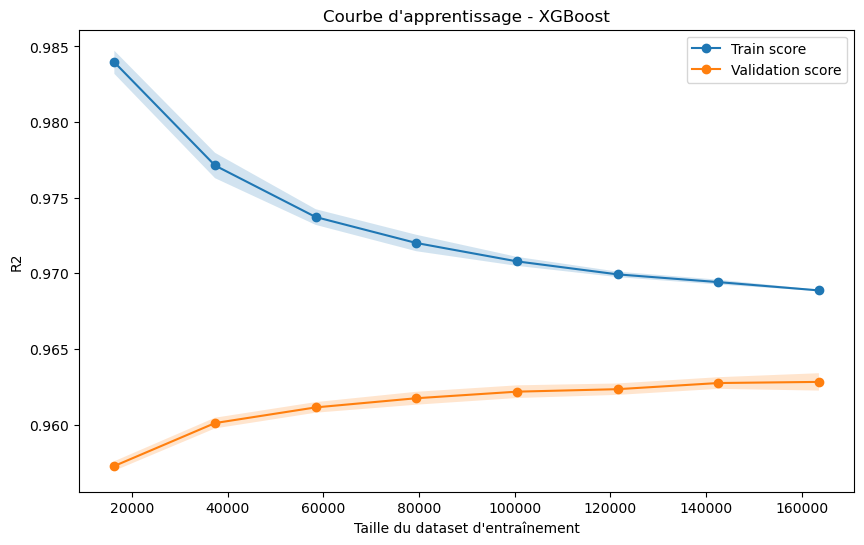

In [28]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Courbe d'apprentissage sur train uniquement
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_train_sel,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Train score', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.plot(train_sizes, test_mean, label='Validation score', marker='o')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2)
plt.title("Courbe d'apprentissage - XGBoost")
plt.xlabel("Taille du dataset d'entraînement")
plt.ylabel('R2')
plt.legend()
plt.show()

## 9. Comparaison des modèles

On compare trois modèles entraînés sur le même `X_train_sel` et évalués sur le même `X_test_sel` :
- **Baseline XGB** — paramètres fixes sans optimisation
- **XGBoost Optuna** — hyperparamètres optimisés par TPE (100 trials)
- **CatBoost Optuna** — hyperparamètres optimisés par TPE (100 trials)

In [29]:
comparison_models_df = pd.DataFrame({
    "Modèle": ["XGBoost Baseline", "XGBoost Optuna", "CatBoost Optuna"],
    "MAE": [
        mean_absolute_error(y_test, xgb_pred_baseline),
        mean_absolute_error(y_test, xgb_pred_optuna),
        mean_absolute_error(y_test, cat_pred_optuna)
    ],
    "RMSE": [
        mean_squared_error(y_test, xgb_pred_baseline) ** 0.5,
        mean_squared_error(y_test, xgb_pred_optuna) ** 0.5,
        mean_squared_error(y_test, cat_pred_optuna) ** 0.5
    ],
    "R2": [
        r2_score(y_test, xgb_pred_baseline),
        r2_score(y_test, xgb_pred_optuna),
        r2_score(y_test, cat_pred_optuna)
    ]
})

display(comparison_models_df)

,Modèle,MAE,RMSE,R2
0,XGBoost Baseline,1.056760,1.889271,0.963271
1,XGBoost Optuna,0.896037,1.768965,0.967799
2,CatBoost Optuna,0.894154,1.782264,0.967313


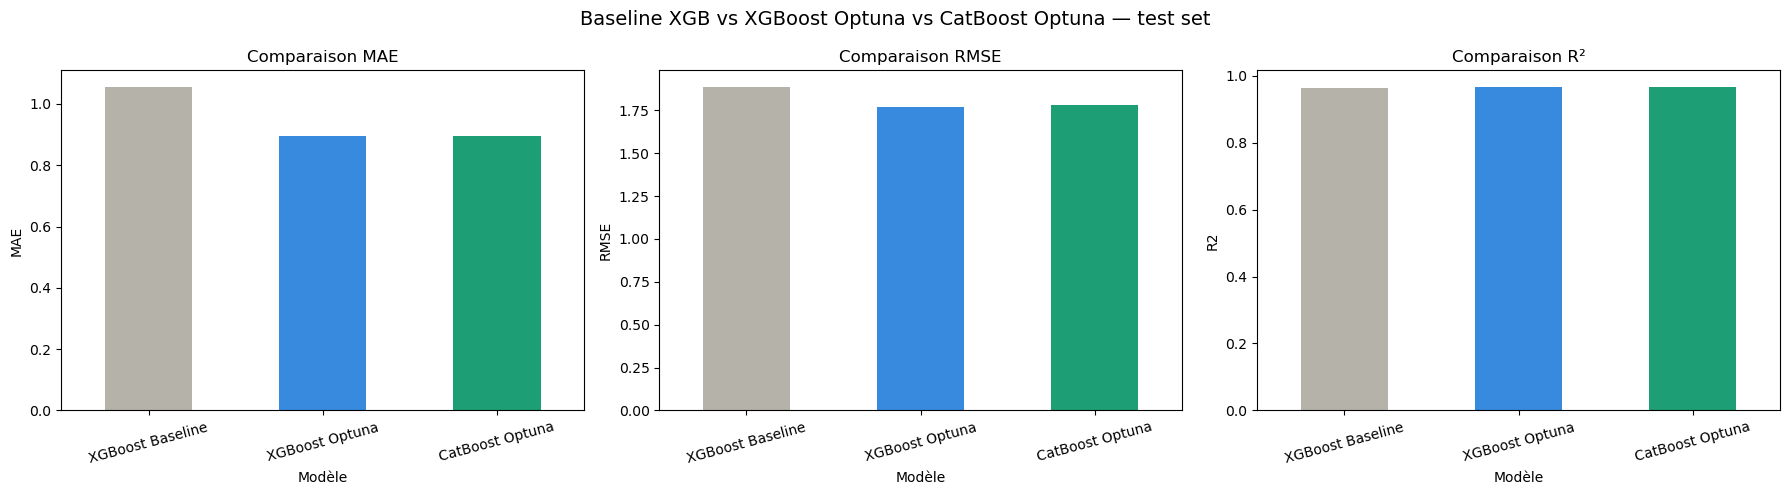

Exception ignored in: <function ResourceTracker.__del__ at 0x104be1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104ce1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1052a9bc0>
Traceback (most recent call last

In [30]:
plot_df = comparison_models_df.set_index("Modèle")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_df["MAE"].plot(kind="bar", ax=axes[0], color=["#B4B2A9", "#378ADD", "#1D9E75"])
axes[0].set_title("Comparaison MAE")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis='x', rotation=15)

plot_df["RMSE"].plot(kind="bar", ax=axes[1], color=["#B4B2A9", "#378ADD", "#1D9E75"])
axes[1].set_title("Comparaison RMSE")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis='x', rotation=15)

plot_df["R2"].plot(kind="bar", ax=axes[2], color=["#B4B2A9", "#378ADD", "#1D9E75"])
axes[2].set_title("Comparaison R²")
axes[2].set_ylabel("R2")
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle("Baseline XGB vs XGBoost Optuna vs CatBoost Optuna — test set", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Analyse détaillée des performances

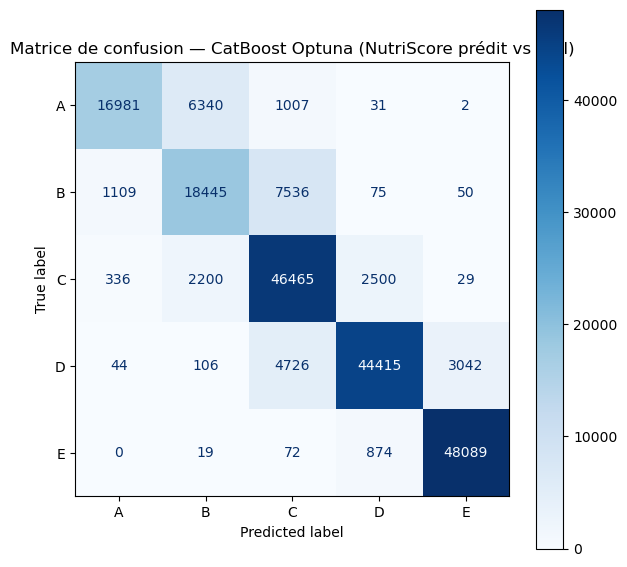

Accuracy NutriScore (A–E) : 0.8528

Classification report :
              precision    recall  f1-score   support

           A       0.92      0.70      0.79     24361
           B       0.68      0.68      0.68     27215
           C       0.78      0.90      0.83     51530
           D       0.93      0.85      0.89     52333
           E       0.94      0.98      0.96     49054

    accuracy                           0.85    204493
   macro avg       0.85      0.82      0.83    204493
weighted avg       0.86      0.85      0.85    204493



In [31]:
# Conversion des scores numériques en grades A–E (utilise score_to_grade défini en section 4)
y_pred_score = cat_model_optuna.predict(X_test_sel)

y_true_grade = pd.Series(y_test).apply(score_to_grade).reset_index(drop=True)
y_pred_grade = pd.Series(y_pred_score).apply(score_to_grade)

labels = ["A", "B", "C", "D", "E"]

cm = confusion_matrix(y_true_grade, y_pred_grade, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Matrice de confusion — CatBoost Optuna (NutriScore prédit vs réel)")
plt.show()

acc = accuracy_score(y_true_grade, y_pred_grade)
print(f"Accuracy NutriScore (A–E) : {acc:.4f}\n")
print("Classification report :")
print(classification_report(y_true_grade, y_pred_grade, labels=labels))

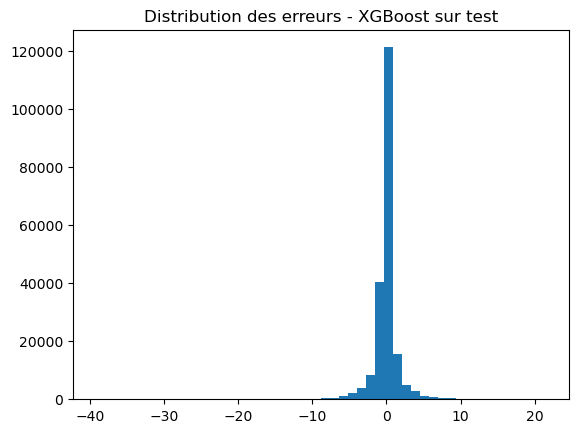

In [32]:
import matplotlib.pyplot as plt

errors = y_test - xgb_pred_optuna

plt.hist(errors, bins=50)
plt.title('Distribution des erreurs - XGBoost sur test')
plt.show()


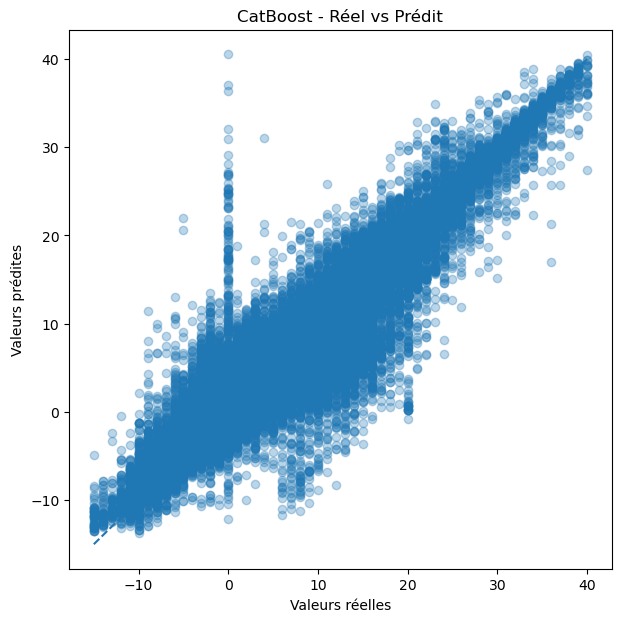

In [33]:
comparison_cat_df = pd.DataFrame({
    'y_test': y_test.reset_index(drop=True),
    'y_pred_catboost': pd.Series(cat_pred_optuna)
})

comparison_cat_df.head()

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_test, cat_pred_optuna, alpha=0.3)
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("CatBoost - Réel vs Prédit")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.show()

In [34]:
results_grades = pd.DataFrame({
    'true_score': y_test.reset_index(drop=True),
    'pred_score': y_pred_score,
    'true_grade': y_true_grade,
    'pred_grade': y_pred_grade
})
display(results_grades.head(20))

,true_score,pred_score,true_grade,pred_grade
0,3.0,3.038201,C,C
1,27.0,26.923215,E,E
2,-4.0,-3.071103,A,A
3,7.0,8.066416,C,C
4,22.0,13.477975,E,D
5,3.0,0.200073,C,B
6,12.0,11.750471,D,D
7,8.0,6.611064,C,C
8,-4.0,-3.754536,A,A
9,2.0,2.662169,B,C


## 11. Contrôle final du protocole

In [35]:

print('Intersection train/test :', len(set(train_df.index) & set(test_df.index)))
print('\nColonnes utilisées par le modèle :')
print(selected_features)
print('\nLa cible est-elle dans les features ? ', target_col in selected_features)
print('nutriscore_grade est-il dans les features ? ', 'nutriscore_grade' in selected_features)
print('nutriscore_score est-il dans X_test ? ', target_col in X_test.columns)
print('nutriscore_grade est-il dans X_test ? ', 'nutriscore_grade' in X_test.columns)


Intersection train/test : 0

Colonnes utilisées par le modèle :
['energy_100g', 'fat_100g', 'saturated-fat_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'carbohydrates_100g', 'salt_100g', 'non_zero_features', 'total_macro_100g', 'sugar_to_carb_ratio', 'satfat_to_fat_ratio', 'protein_to_energy_ratio', 'fiber_to_carb_ratio']

La cible est-elle dans les features ?  False
nutriscore_grade est-il dans les features ?  False
nutriscore_score est-il dans X_test ?  False
nutriscore_grade est-il dans X_test ?  False


In [36]:
# Contrôle final du protocole
print('Le modèle a été entraîné sur X_train uniquement :', X_train.shape)
print('Le modèle a été évalué sur X_test uniquement    :', X_test.shape)
print('Proportion train :', round(len(X_train) / len(training_df), 3))
print('Proportion test  :', round(len(X_test) / len(training_df), 3))


Le modèle a été entraîné sur X_train uniquement : (204492, 14)
Le modèle a été évalué sur X_test uniquement    : (204493, 14)
Proportion train : 0.5
Proportion test  : 0.5
